# Qadence Kickstart: Variational Circuits, Geometric ML & Physics-Informed Learning

**Lessons 09 + 10 + 11 of the QML study guide.**

This trio is the *variational* heart of QML — the half that runs a real parameterized quantum circuit:

1. **Lesson 09 — Variational quantum circuits.** Build a parameterized circuit from scratch in PyTorch, train
   it as a classifier, and derive the **parameter-shift rule** — the gradient method that makes QML trainable on
   actual hardware. This is the model Pasqal's Qadence is built to construct and differentiate.
2. **Lesson 10 — Expressivity & geometry.** What functions can a circuit represent? (A **truncated Fourier
   series**.) And how does building in **symmetry** buy trainability and generalization?
3. **Lesson 11 — Physics-informed ML.** Put a differential equation *in the loss* and let autograd solve it —
   the classical blueprint for Pasqal's **differentiable quantum circuit (DQC)** PDE solvers.

> **Enhancements beyond the study-guide text:** a visualization of *why* parameter-shift works (the output is a
> sinusoid in each angle); **data re-uploading** breaking the encoding's even-symmetry bias to fit an odd
> target; **shot-noise** gradients (the real-hardware reality); an empirical **qubits → Fourier-frequencies**
> spectrum; a **symmetry-aware vs. agnostic** generalization gap on graphs; and a fully simulated **quantum
> PINN** (single qubit, exact param-shift derivatives) solving the harmonic oscillator.

**Prereqs:** Lessons 01 (autograd), 06 (state vectors, `kron`), 07 (classifier training).


## Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from sklearn.linear_model import LogisticRegression

torch.manual_seed(20000)
print("setup ready")

setup ready


---
# Lesson 09 — Variational Quantum Circuits (Simulated)

## 1. Qubits, gates, and states as tensors

A state is a length-`2ⁿ` complex vector; a gate is a unitary matrix applied to it. We build the few gates we
need: single-qubit rotations `Ry`, `Rz`, an embedder `on_qubit` (lift a 1-qubit gate into the n-qubit space via
`kron`), and the entangling **CNOT**. Entanglement is what gives the model access to correlations a product
state cannot represent.

In [2]:
I2 = torch.eye(2, dtype=torch.cfloat)

def Ry(theta):
    theta = torch.as_tensor(theta, dtype=torch.float)
    c, s = torch.cos(theta/2), torch.sin(theta/2)
    return torch.stack([torch.stack([c, -s]), torch.stack([s, c])]).cfloat()

def Rz(theta):
    theta = torch.as_tensor(theta, dtype=torch.float)
    z = torch.zeros((), dtype=torch.cfloat)
    return torch.stack([torch.stack([torch.exp(-1j*theta/2), z]),
                        torch.stack([z, torch.exp(1j*theta/2)])])

def on_qubit(gate, q, n):
    """Embed a single-qubit gate acting on qubit q into the full n-qubit space."""
    ops = [gate if i == q else I2 for i in range(n)]
    full = ops[0]
    for op in ops[1:]:
        full = torch.kron(full, op)
    return full

def cnot(control, target, n):
    dim = 2**n; U = torch.zeros(dim, dim, dtype=torch.cfloat)
    for b in range(dim):
        bits = [(b >> (n-1-k)) & 1 for k in range(n)]
        if bits[control] == 1:
            bits[target] ^= 1
        U[sum(bit << (n-1-k) for k, bit in enumerate(bits)), b] = 1.0
    return U

n = 2
psi0 = torch.zeros(2**n, dtype=torch.cfloat); psi0[0] = 1.0    # |00>
print("start state |00>:", psi0.real.tolist())
print("CNOT(0,1) on 2 qubits:")
print(cnot(0, 1, 2).real.int().tolist())

start state |00>: [1.0, 0.0, 0.0, 0.0]
CNOT(0,1) on 2 qubits:
[[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]]


## 2. A variational classifier

The recipe mirrors Lesson 07's neural classifier, with a circuit as the model:
**encode** data into rotation angles → **entangle** → **variational** trainable rotations → **entangle** →
**measure** an observable `⟨Z₀⟩ ∈ [−1, 1]`. The measured expectation is the output; `loss.backward()` works
because every gate is a differentiable torch op — exactly how Qadence's simulator backend trains.

We classify **inner vs. outer**: label `+1` if `|x| < 0.75`, else `−1`.

final loss 0.399   accuracy 95.00%


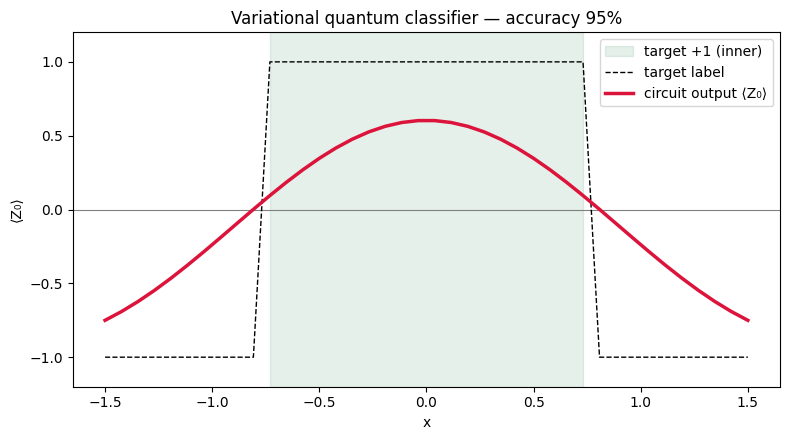

In [3]:
Z = torch.tensor([[1, 0], [0, -1]], dtype=torch.cfloat)
OBS = on_qubit(Z, 0, n)        # observable: Z on qubit 0
ENT = cnot(0, 1, n)

def circuit(x, theta):
    psi = torch.zeros(2**n, dtype=torch.cfloat); psi[0] = 1.0
    for q in range(n):                       # data encoding (feature map)
        psi = on_qubit(Ry(x), q, n) @ psi
    psi = ENT @ psi
    for q in range(n):                       # variational layer
        psi = on_qubit(Ry(theta[q]), q, n) @ psi
    psi = ENT @ psi
    return torch.vdot(psi, OBS @ psi).real   # <Z_0>

torch.manual_seed(0)
theta = (torch.rand(n) * 6.28).requires_grad_(True)
opt = torch.optim.Adam([theta], lr=0.1)
xs = torch.linspace(-1.5, 1.5, 40)
ys = torch.where(xs.abs() < 0.75, 1.0, -1.0)
for step in range(200):
    opt.zero_grad()
    preds = torch.stack([circuit(x, theta) for x in xs])
    loss = ((preds - ys) ** 2).mean()
    loss.backward(); opt.step()
preds = torch.stack([circuit(x, theta) for x in xs]).detach()
acc = ((preds > 0) == (ys > 0)).float().mean()
print(f"final loss {loss.item():.3f}   accuracy {acc.item():.2%}")

plt.figure(figsize=(8, 4.5))
plt.axhline(0, color='gray', lw=0.8)
plt.fill_between(xs, -1.2, 1.2, where=ys > 0, color='seagreen', alpha=0.12, label='target +1 (inner)')
plt.plot(xs, ys, 'k--', lw=1, label='target label')
plt.plot(xs, preds, 'crimson', lw=2.5, label='circuit output ⟨Z₀⟩')
plt.title(f'Variational quantum classifier — accuracy {acc.item():.0%}')
plt.xlabel('x'); plt.ylabel('⟨Z₀⟩'); plt.ylim(-1.2, 1.2); plt.legend()
plt.tight_layout(); plt.show()

## 3. Inductive bias from the encoding (and how to break it)

**Why inner/outer, and not `sign(x)`?** With an `Ry(x)` encoding read out through `⟨Z₀⟩`, this circuit's output
is an **even** function of `x`: `circuit(−x, θ) == circuit(x, θ)`. So it *physically cannot* represent an odd
target like `sign(x)` — training would stall near 50%. The data-encoding scheme decides what functions are even
*representable*, before any training. This is **inductive bias** (Lesson 10) you can feel with your hands.

The fix is a richer encoding: **data re-uploading** — interleave encode/variational layers several times. The
trainable rotations *between* re-encodings break the even symmetry. We show the single-encode circuit failing on
`sign(x)` and a 3-layer re-uploading circuit succeeding (exercise 2).

even symmetry:  circuit(+0.6) = 0.2443   circuit(-0.6) = 0.2443


single-encode on sign(x): accuracy 50%  (stalls — even model, odd target)
re-uploading  on sign(x): accuracy 100%  (succeeds — symmetry broken)


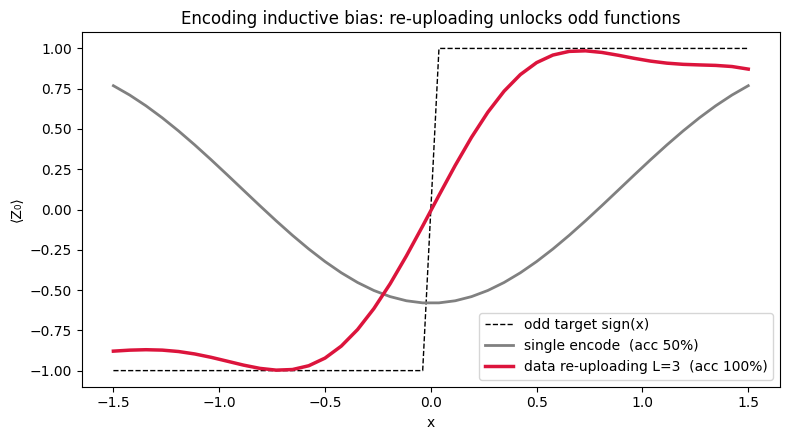

In [4]:
# confirm the even symmetry of the single-encode circuit
t = theta.detach()
print("even symmetry:  circuit(+0.6) =", round(circuit(torch.tensor(0.6), t).item(), 4),
      "  circuit(-0.6) =", round(circuit(torch.tensor(-0.6), t).item(), 4))

def circuit_reup(x, th, L):
    """Data re-uploading: L blocks of [encode Ry(x)] then [trainable Rz,Ry per qubit] then entangle."""
    psi = torch.zeros(2**n, dtype=torch.cfloat); psi[0] = 1.0
    for l in range(L):
        for q in range(n):
            psi = on_qubit(Ry(x), q, n) @ psi
        for q in range(n):
            psi = on_qubit(Rz(th[l, q, 0]), q, n) @ psi
            psi = on_qubit(Ry(th[l, q, 1]), q, n) @ psi
        psi = ENT @ psi
    return torch.vdot(psi, OBS @ psi).real

xs = torch.linspace(-1.5, 1.5, 40); ys_odd = torch.sign(xs)

# (a) single-encode circuit on the ODD target -> stalls
torch.manual_seed(2)
th_s = (torch.rand(n) * 6.28).requires_grad_(True); opt_s = torch.optim.Adam([th_s], lr=0.1)
for _ in range(200):
    opt_s.zero_grad(); ((torch.stack([circuit(x, th_s) for x in xs]) - ys_odd) ** 2).mean().backward(); opt_s.step()
pred_s = torch.stack([circuit(x, th_s) for x in xs]).detach()
acc_s = ((pred_s > 0) == (ys_odd > 0)).float().mean()

# (b) data re-uploading (L=3) -> fits the odd target
L = 3
torch.manual_seed(1)
th_r = (torch.rand(L, n, 2) * 6.28).requires_grad_(True); opt_r = torch.optim.Adam([th_r], lr=0.1)
for _ in range(400):
    opt_r.zero_grad(); ((torch.stack([circuit_reup(x, th_r, L) for x in xs]) - ys_odd) ** 2).mean().backward(); opt_r.step()
pred_r = torch.stack([circuit_reup(x, th_r, L) for x in xs]).detach()
acc_r = ((pred_r > 0) == (ys_odd > 0)).float().mean()

print(f"single-encode on sign(x): accuracy {acc_s.item():.0%}  (stalls — even model, odd target)")
print(f"re-uploading  on sign(x): accuracy {acc_r.item():.0%}  (succeeds — symmetry broken)")

plt.figure(figsize=(8, 4.5))
plt.plot(xs, ys_odd, 'k--', lw=1, label='odd target sign(x)')
plt.plot(xs, pred_s, 'gray', lw=2, label=f'single encode  (acc {acc_s.item():.0%})')
plt.plot(xs, pred_r, 'crimson', lw=2.5, label=f'data re-uploading L=3  (acc {acc_r.item():.0%})')
plt.title('Encoding inductive bias: re-uploading unlocks odd functions')
plt.xlabel('x'); plt.ylabel('⟨Z₀⟩'); plt.legend(); plt.tight_layout(); plt.show()

## 4. The parameter-shift rule

On a *real* device you can't backprop through the physics — you only get expectation values. The
**parameter-shift rule** recovers an **exact** gradient from two extra circuit evaluations:

$$\frac{\partial \langle O \rangle}{\partial \theta} = \tfrac{1}{2}\big[\, f(\theta + \tfrac{\pi}{2}) - f(\theta - \tfrac{\pi}{2}) \,\big]$$

for gates of the form `exp(−iθP/2)` (like `Ry`, `Rz`). It works because the output is a pure **sinusoid** in
each angle — so two samples a quarter-period apart pin down the slope exactly. We verify it matches autodiff,
then *visualize why*.

autodiff        : [-0.86783, -0.0]
parameter-shift : [-0.86783, -0.0]
match           : True


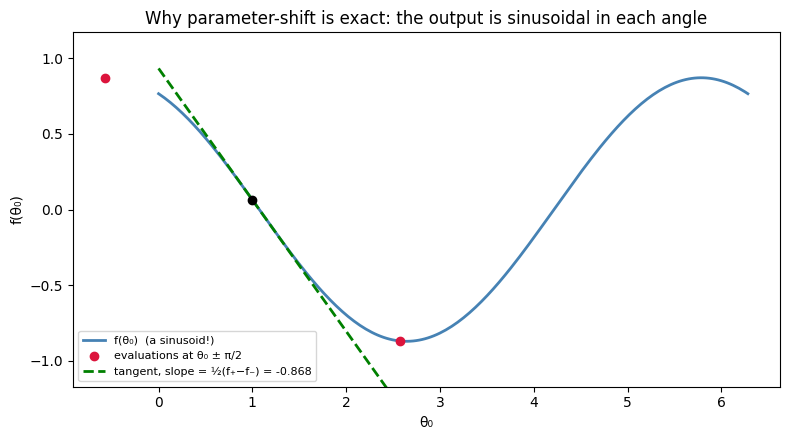

In [5]:
def f(theta_vec):                              # scalar circuit output as a function of theta
    return circuit(torch.tensor(0.7), theta_vec)

theta = torch.tensor([1.0, 2.0], requires_grad=True)
out = f(theta); out.backward()
autodiff_grad = theta.grad.clone()

shift = torch.pi / 2
ps_grad = torch.zeros(2)
for i in range(2):
    tp = theta.detach().clone(); tp[i] += shift
    tm = theta.detach().clone(); tm[i] -= shift
    ps_grad[i] = 0.5 * (f(tp) - f(tm))

print("autodiff        :", [round(v, 5) for v in autodiff_grad.tolist()])
print("parameter-shift :", [round(v, 5) for v in ps_grad.tolist()])
print("match           :", torch.allclose(autodiff_grad, ps_grad, atol=1e-4))

# visualize: f as a function of theta[0] is a sinusoid; the shift points give the exact slope
th0_star, th1_fixed = 1.0, 2.0
grid = torch.linspace(0, 2*torch.pi, 200)
fvals = torch.stack([f(torch.tensor([g.item(), th1_fixed])) for g in grid]).detach()
s = float(shift)
fp = f(torch.tensor([th0_star + s, th1_fixed])).item()
fm = f(torch.tensor([th0_star - s, th1_fixed])).item()
f0 = f(torch.tensor([th0_star, th1_fixed])).item()
grad0 = 0.5 * (fp - fm)

plt.figure(figsize=(8, 4.5))
plt.plot(grid, fvals, 'steelblue', lw=2, label='f(θ₀)  (a sinusoid!)')
plt.scatter([th0_star - s, th0_star + s], [fm, fp], c='crimson', zorder=5,
            label='evaluations at θ₀ ± π/2')
tang = f0 + grad0 * (grid - th0_star)
plt.plot(grid, tang, 'green', ls='--', lw=2, label=f'tangent, slope = ½(f₊−f₋) = {grad0:.3f}')
plt.scatter([th0_star], [f0], c='black', zorder=5)
plt.title('Why parameter-shift is exact: the output is sinusoidal in each angle')
plt.xlabel('θ₀'); plt.ylabel('f(θ₀)'); plt.ylim(fvals.min()-0.3, fvals.max()+0.3)
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 5. Shot noise — the real-hardware reality (exercise 3)

A real device estimates `⟨Z₀⟩` from a *finite* number of measurement **shots**, so `f(θ)` is noisy and the
parameter-shift gradient is a random variable. Its standard deviation shrinks like `1/√shots`. Below we draw 200
gradient estimates at 10 / 100 / 1000 shots and compare to the exact value — the spread you'd actually fight on
hardware.

shots=   10:  mean -0.853   std 0.121
shots=  100:  mean -0.871   std 0.034


shots= 1000:  mean -0.867   std 0.011


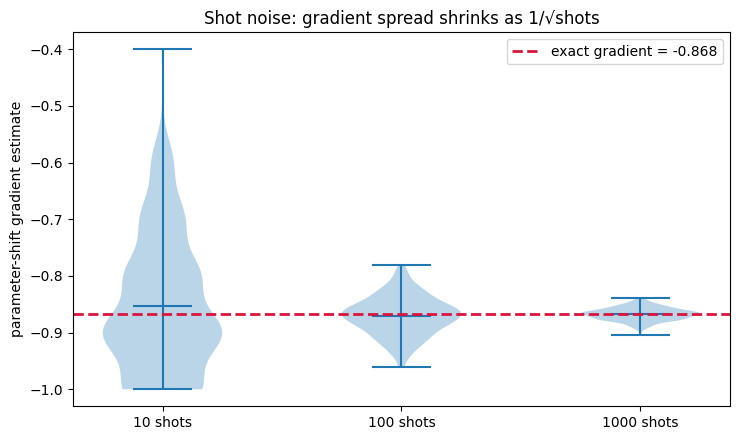

In [6]:
def estimate_f(x, tv, shots):
    psi = torch.zeros(2**n, dtype=torch.cfloat); psi[0] = 1.0
    for q in range(n): psi = on_qubit(Ry(x), q, n) @ psi
    psi = ENT @ psi
    for q in range(n): psi = on_qubit(Ry(tv[q]), q, n) @ psi
    psi = ENT @ psi
    probs = (psi.conj() * psi).real
    idx = torch.arange(2**n)
    p0 = probs[(idx >> (n-1)) & 1 == 0].sum()              # P(qubit 0 measures |0>)
    counts0 = torch.distributions.Binomial(shots, p0.clamp(0, 1)).sample()
    return 2 * (counts0 / shots) - 1                        # estimator of <Z_0>

th = torch.tensor([1.0, 2.0]); x0 = torch.tensor(0.7); shift = torch.pi / 2
exact = ps_grad[0].item()
shot_list = [10, 100, 1000]
samples = []
for shots in shot_list:
    g = []
    for _ in range(200):
        tp = th.clone(); tp[0] += shift; tm = th.clone(); tm[0] -= shift
        g.append(0.5 * (estimate_f(x0, tp, shots) - estimate_f(x0, tm, shots)).item())
    samples.append(g)
    print(f"shots={shots:5d}:  mean {np.mean(g):+.3f}   std {np.std(g):.3f}")

plt.figure(figsize=(7.5, 4.5))
parts = plt.violinplot(samples, showmeans=True)
plt.axhline(exact, color='crimson', ls='--', lw=2, label=f'exact gradient = {exact:.3f}')
plt.xticks([1, 2, 3], [f'{s} shots' for s in shot_list])
plt.ylabel('parameter-shift gradient estimate')
plt.title('Shot noise: gradient spread shrinks as 1/√shots')
plt.legend(); plt.tight_layout(); plt.show()

**Connections.** The encoding layer is a quantum *feature map* (Lesson 06) — push it and you get quantum
kernels. Add depth/width and the §4 gradients shrink exponentially → **barren plateaus** (Lesson 05). Swap the
loss for an MMD over samples → a **Born machine** (Lesson 08). Wrap it in an `nn.Module` with classical layers →
a **hybrid model** (Lesson 12).

---
# Lesson 10 — Expressivity & Geometric / Equivariant ML

## 1. Expressivity = the function class a model can represent

More parameters/depth → richer functions, but also harder training and worse small-data generalization. Using
polynomial **degree** as an expressivity dial, we fit `sin(5x)`: low degree underfits, high degree captures the
wiggles.

degree  1: fit error 0.4998
degree  3: fit error 0.1340
degree  7: fit error 0.0001
degree 15: fit error 0.0000


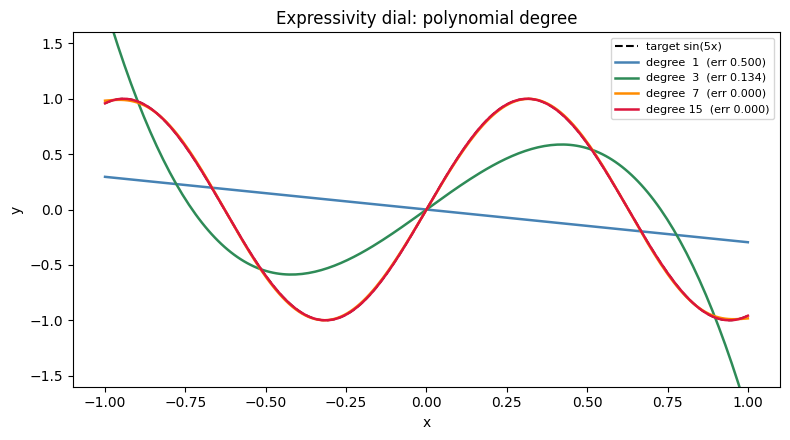

In [7]:
torch.manual_seed(0)
x = torch.linspace(-1, 1, 200)
target = torch.sin(5 * x)

plt.figure(figsize=(8, 4.5))
plt.plot(x, target, 'k--', lw=1.5, label='target sin(5x)')
for degree, col in zip([1, 3, 7, 15], ['steelblue', 'seagreen', 'darkorange', 'crimson']):
    Phi = torch.stack([x ** d for d in range(degree + 1)], dim=1)
    coef = torch.linalg.lstsq(Phi, target.unsqueeze(1)).solution
    fit = (Phi @ coef).squeeze()
    err = (fit - target).pow(2).mean().item()
    plt.plot(x, fit, color=col, lw=1.8, label=f'degree {degree:2d}  (err {err:.3f})')
    print(f'degree {degree:2d}: fit error {err:.4f}')
plt.title('Expressivity dial: polynomial degree')
plt.xlabel('x'); plt.ylabel('y'); plt.ylim(-1.6, 1.6); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Quantum models are (truncated) Fourier series

A key theoretical handle: a variational circuit whose data-encoding gates are `Ry(x)`-type rotations outputs a
**truncated Fourier series in x** — frequencies set by the *encoding*, coefficients set by the *trainable
parameters*. We demonstrate by fitting a square wave (rich in odd harmonics) with `K` accessible frequencies.

max frequency K=1: fit error 0.1921
max frequency K=3: fit error 0.1024
max frequency K=9: fit error 0.0437


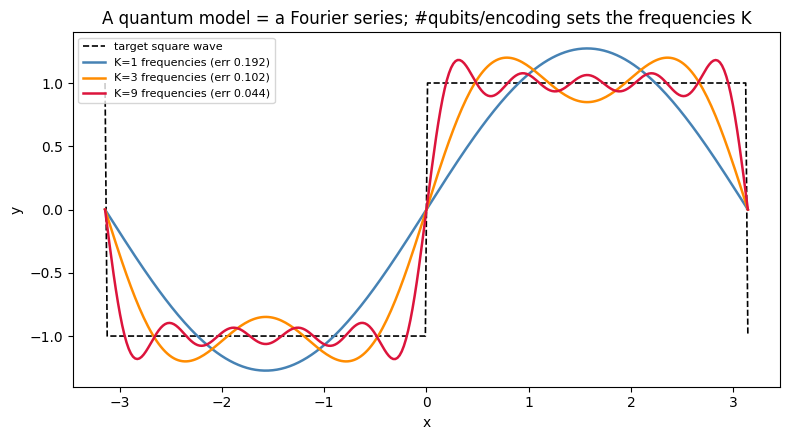

In [8]:
torch.manual_seed(0)
x = torch.linspace(-torch.pi, torch.pi, 300)
target = torch.sign(torch.sin(x))          # square wave

def fourier_features(x, K):
    feats = [torch.ones_like(x)]
    for k in range(1, K + 1):
        feats += [torch.cos(k * x), torch.sin(k * x)]
    return torch.stack(feats, dim=1)

plt.figure(figsize=(8, 4.5))
plt.plot(x, target, 'k--', lw=1.2, label='target square wave')
for K, col in zip([1, 3, 9], ['steelblue', 'darkorange', 'crimson']):
    Phi = fourier_features(x, K)
    coef = torch.linalg.lstsq(Phi, target.unsqueeze(1)).solution
    fit = (Phi @ coef).squeeze()
    err = (fit - target).pow(2).mean().item()
    plt.plot(x, fit, color=col, lw=1.8, label=f'K={K} frequencies (err {err:.3f})')
    print(f'max frequency K={K}: fit error {err:.4f}')
plt.title('A quantum model = a Fourier series; #qubits/encoding sets the frequencies K')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

**Enhancement — qubits → frequencies (exercise 1).** For a product `Ry(x)` encoding measured through a
parity observable, the output is `cos(x)ⁿ`, whose frequencies *add* up to `n`. The FFT below makes it concrete:
the **highest accessible frequency equals the qubit count**. So encoding design — not just depth — governs what
the circuit can express.

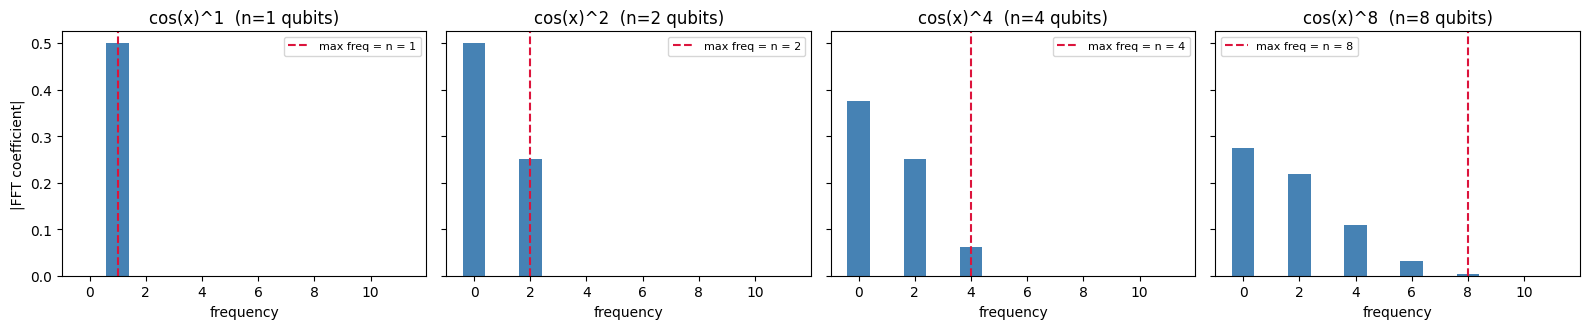

Highest accessible frequency grows one-for-one with qubit count.


In [9]:
N = 512
xg = torch.linspace(0, 2 * torch.pi, N + 1)[:-1]           # [0, 2π), no endpoint duplication
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4), sharey=True)
for ax, nq in zip(axes, [1, 2, 4, 8]):
    spec = torch.abs(torch.fft.rfft(torch.cos(xg) ** nq)) / N
    maxf = int(torch.nonzero(spec > 1e-6 * spec.sum()).max())
    ax.bar(range(12), spec[:12].numpy(), color='steelblue')
    ax.axvline(nq, color='crimson', ls='--', label=f'max freq = n = {nq}')
    ax.set_title(f'cos(x)^{nq}  (n={nq} qubits)'); ax.set_xlabel('frequency'); ax.legend(fontsize=8)
axes[0].set_ylabel('|FFT coefficient|')
plt.tight_layout(); plt.show()
print("Highest accessible frequency grows one-for-one with qubit count.")

## 3. Symmetry: the antidote to over-expressivity

If a problem is invariant under some transformation (relabeling graph nodes, rotating an image), build that
invariance into the model. It then *can't* waste capacity on symmetry-violating functions — a smaller effective
hypothesis space, better generalization, fewer barren plateaus.

First, the core distinction: a **non-invariant** feature (flattened adjacency) changes under node relabeling,
while **invariant** features (sorted degree sequence, `tr(A²)`, edge count) do not. And an **equivariant**
aggregation (sum over neighbours, `A·h`) transforms *consistently* with the permutation.

In [10]:
# two orderings of the SAME 3-node graph
A = torch.tensor([[0., 1, 1], [1, 0, 0], [1, 0, 0]])
P = torch.eye(3)[torch.tensor([2, 0, 1])]      # a permutation matrix
A_perm = P @ A @ P.T

def invariants(A):
    deg = torch.sort(A.sum(1)).values
    return torch.cat([deg, torch.tensor([torch.trace(A @ A), A.sum()])])

print("flattened adjacency equal under relabeling? ", torch.allclose(A.flatten(), A_perm.flatten()))
print("invariant features  equal under relabeling? ", torch.allclose(invariants(A), invariants(A_perm)))

# equivariance: aggregating neighbour features commutes with permutation
h = torch.tensor([1., 2., 3.])
lhs = P @ (A @ h)            # permute the result of aggregation
rhs = (P @ A @ P.T) @ (P @ h)  # aggregate on the permuted graph/features
print("equivariant aggregation A·h commutes with P:", torch.allclose(lhs, rhs))

flattened adjacency equal under relabeling?  False
invariant features  equal under relabeling?  True
equivariant aggregation A·h commutes with P: True


**Enhancement — the generalization payoff (exercise 3).** We classify **stars vs. paths** on 4 nodes —
chosen to have the *same edge count* (3 each), so edge-counting alone can't cheat; only *structure* separates
them. We train both models on graphs in a single canonical ordering, then test on **randomly permuted** versions
(unseen orderings). The symmetry-*agnostic* model (flattened adjacency) memorizes positions and collapses on new
orderings; the symmetry-*aware* model (invariant features) generalizes perfectly.

star edges = 3, path edges = 3  (equal -> edge count can't separate)
symmetry-AGNOSTIC (flattened) test acc: 61%
symmetry-AWARE   (invariant)  test acc: 100%


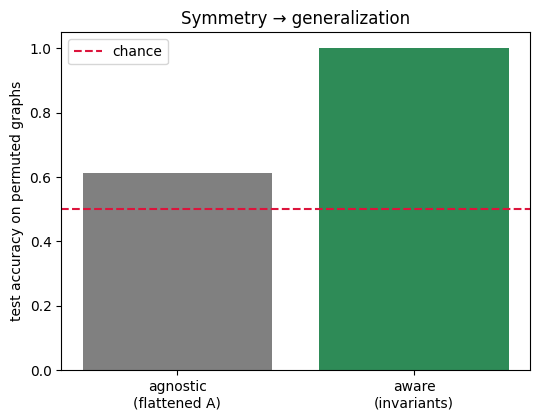

In [11]:
def star4():
    A = torch.zeros(4, 4)
    for j in (1, 2, 3): A[0, j] = A[j, 0] = 1     # center 0 -> {1,2,3}; degrees [3,1,1,1]
    return A
def path4():
    A = torch.zeros(4, 4)
    for i, j in [(0, 1), (1, 2), (2, 3)]: A[i, j] = A[j, i] = 1   # degrees [1,2,2,1]
    return A
def perm4(A):
    P = torch.eye(4)[torch.randperm(4)]; return P @ A @ P.T

print(f"star edges = {int(star4().sum()//2)}, path edges = {int(path4().sum()//2)}  (equal -> edge count can't separate)")

torch.manual_seed(0)
# TRAIN on the canonical ordering only
Xf_tr = torch.stack([star4().flatten()] * 15 + [path4().flatten()] * 15).numpy()
Xi_tr = torch.stack([invariants(star4())] * 15 + [invariants(path4())] * 15).numpy()
ytr = np.array([0] * 15 + [1] * 15)
# TEST on random permutations (unseen orderings)
test = [(perm4(star4()), 0) for _ in range(40)] + [(perm4(path4()), 1) for _ in range(40)]
Xf_te = torch.stack([A.flatten() for A, _ in test]).numpy()
Xi_te = torch.stack([invariants(A) for A, _ in test]).numpy()
yte = np.array([l for _, l in test])

acc_agnostic = LogisticRegression(max_iter=2000).fit(Xf_tr, ytr).score(Xf_te, yte)
acc_aware    = LogisticRegression(max_iter=2000).fit(Xi_tr, ytr).score(Xi_te, yte)
print(f"symmetry-AGNOSTIC (flattened) test acc: {acc_agnostic:.0%}")
print(f"symmetry-AWARE   (invariant)  test acc: {acc_aware:.0%}")

plt.figure(figsize=(5.5, 4.3))
bars = plt.bar(['agnostic\n(flattened A)', 'aware\n(invariants)'], [acc_agnostic, acc_aware],
               color=['gray', 'seagreen'])
plt.axhline(0.5, color='crimson', ls='--', label='chance'); plt.ylim(0, 1.05)
plt.ylabel('test accuracy on permuted graphs'); plt.title('Symmetry → generalization')
plt.legend(); plt.tight_layout(); plt.show()

## 4. Why this matters for Pasqal QML

- **Graph tasks (QEK):** permutation symmetry is built into the kernel *by construction* — a big reason QEK is a
  sensible graph method.
- **Avoiding concentration:** symmetry-structured kernels can keep a quantum advantage *without* the exponential
  concentration that kills generic quantum kernels (`arXiv:2509.14337`).
- **Hardware-native symmetry:** neutral-atom registers have geometric symmetries that can be matched to the
  problem's.

The guide's recurring theme, stated sharply: **expressivity is cheap; useful, trainable expressivity comes from
encoding the right structure.**

---
# Lesson 11 — Physics-Informed ML & Differential Equations

The idea: train a model to **solve a differential equation by putting the equation itself in the loss**. No
solution data — only the equation and boundary conditions. This is the classical blueprint for Pasqal's
**differentiable quantum circuit (DQC)** PDE solvers.

## 1. Derivatives of a model, for free

Autograd differentiates the model with respect to its *input* (not just its parameters), giving `du/dx`,
`d²u/dx²`, …. `create_graph=True` keeps the derivative itself differentiable — essential for second-order PDEs.

In [12]:
x = torch.linspace(0, 3, 5, requires_grad=True)
u = torch.sin(x)
du, = torch.autograd.grad(u.sum(), x, create_graph=True)   # differentiable derivative
print("du/dx  :", du.round(decimals=3).tolist())
print("cos(x) :", torch.cos(x).round(decimals=3).tolist(), " (they match)")

du/dx  : [1.0, 0.7319999933242798, 0.07100000232458115, -0.628000020980835, -0.9900000095367432]
cos(x) : [1.0, 0.7319999933242798, 0.07100000232458115, -0.628000020980835, -0.9900000095367432]  (they match)


## 2. Physics-informed loss: solve an ODE with no training data

Solve `u'(x) = u(x)`, `u(0) = 1` (solution `eˣ`). The loss has two pieces — the **equation residual** at random
collocation points, and the **boundary condition**. Minimizing it forces the model to *be* the solution.

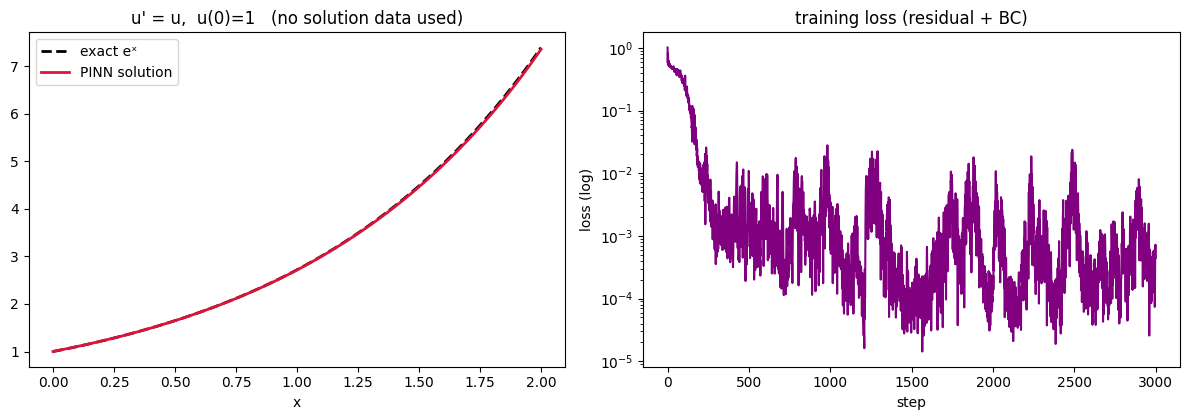

max error vs eˣ: 0.039


In [13]:
torch.manual_seed(0)
model = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh(), nn.Linear(32, 1))
opt = torch.optim.Adam(model.parameters(), lr=0.01)

loss_hist = []
for step in range(3000):
    opt.zero_grad()
    x = torch.rand(64, 1, requires_grad=True) * 2.0            # collocation points in [0, 2]
    ux = model(x)
    dudx, = torch.autograd.grad(ux.sum(), x, create_graph=True)
    loss_ode = ((dudx - ux) ** 2).mean()                       # residual of u' - u = 0
    loss_bc = (model(torch.zeros(1, 1)) - 1.0) ** 2            # u(0) = 1
    loss = loss_ode + loss_bc.squeeze()
    loss.backward(); opt.step(); loss_hist.append(loss.item())

xt = torch.linspace(0, 2, 100).unsqueeze(1)
with torch.no_grad(): pred = model(xt).squeeze()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.plot(xt, torch.exp(xt.squeeze()), 'k--', lw=2, label='exact eˣ')
ax1.plot(xt, pred, 'crimson', lw=2, label='PINN solution')
ax1.set_title("u' = u,  u(0)=1   (no solution data used)"); ax1.set_xlabel('x'); ax1.legend()
ax2.semilogy(loss_hist, color='purple'); ax2.set_title('training loss (residual + BC)')
ax2.set_xlabel('step'); ax2.set_ylabel('loss (log)')
plt.tight_layout(); plt.show()
print("max error vs eˣ:", round((pred - torch.exp(xt.squeeze())).abs().max().item(), 4))

## 3. Second order, and a source term (the structure scales)

Same recipe, one more derivative. Left: the harmonic oscillator `u'' + u = 0`, `u(0)=0`, `u'(0)=1` → `sin(x)`.
Right (**enhancement, exercise 1**): a first-order `u' = −2x·u`, `u(0)=1` → the Gaussian `e^{−x²}`.

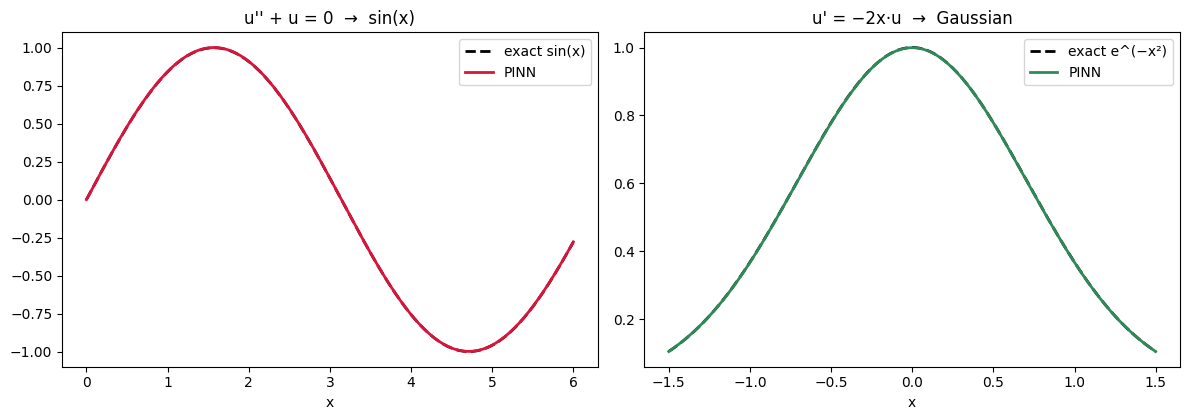

In [14]:
def deriv(y, x):
    return torch.autograd.grad(y.sum(), x, create_graph=True)[0]

# --- harmonic oscillator u'' + u = 0 -> sin(x) ---
torch.manual_seed(0)
m_sho = nn.Sequential(nn.Linear(1, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1))
opt = torch.optim.Adam(m_sho.parameters(), lr=0.005)
for step in range(4000):
    opt.zero_grad()
    x = (torch.rand(64, 1) * 6.0).requires_grad_(True)
    u = m_sho(x); u_xx = deriv(deriv(u, x), x)
    x0 = torch.zeros(1, 1, requires_grad=True); u0 = m_sho(x0); u0_x = deriv(u0, x0)
    loss = ((u_xx + u) ** 2).mean() + (u0 ** 2).squeeze() + ((u0_x - 1.0) ** 2).squeeze()
    loss.backward(); opt.step()

# --- Gaussian: u' = -2x u, u(0)=1 -> exp(-x^2) ---
torch.manual_seed(0)
m_g = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh(), nn.Linear(32, 1))
opt = torch.optim.Adam(m_g.parameters(), lr=0.01)
for step in range(3000):
    opt.zero_grad()
    x = (torch.rand(64, 1) * 3 - 1.5).requires_grad_(True)
    ux = m_g(x); dudx = deriv(ux, x)
    loss = ((dudx + 2 * x * ux) ** 2).mean() + ((m_g(torch.zeros(1, 1)) - 1.0) ** 2).squeeze()
    loss.backward(); opt.step()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
xs1 = torch.linspace(0, 6, 200).unsqueeze(1)
with torch.no_grad(): p1 = m_sho(xs1).squeeze()
ax1.plot(xs1, torch.sin(xs1.squeeze()), 'k--', lw=2, label='exact sin(x)')
ax1.plot(xs1, p1, 'crimson', lw=2, label='PINN')
ax1.set_title("u'' + u = 0  →  sin(x)"); ax1.set_xlabel('x'); ax1.legend()
xs2 = torch.linspace(-1.5, 1.5, 200).unsqueeze(1)
with torch.no_grad(): p2 = m_g(xs2).squeeze()
ax2.plot(xs2, torch.exp(-xs2.squeeze() ** 2), 'k--', lw=2, label='exact e^(−x²)')
ax2.plot(xs2, p2, 'seagreen', lw=2, label='PINN')
ax2.set_title("u' = −2x·u  →  Gaussian"); ax2.set_xlabel('x'); ax2.legend()
plt.tight_layout(); plt.show()

## 4. A *quantum* PINN, in simulation (exercise 3 + the grand finale)

We now replace the neural net with a **quantum circuit** and obtain its derivatives via the **parameter-shift
rule** (Lesson 09) — a fully quantum PINN, the essence of Pasqal's DQC.

**The careful part.** Parameter-shift gives `du/dx` cleanly only when `x` enters through a *single* gate. So we
use a **single qubit with one encoding gate** `Ry(x)`, followed by a trainable `Rz·Ry·Rz`, read out as `⟨Z⟩`.
Its output is a frequency-1 Fourier function, for which:

$$u'(x) = \tfrac12\big[u(x+\tfrac{\pi}{2}) - u(x-\tfrac{\pi}{2})\big], \qquad u''(x) = \tfrac14\big[u(x+\pi) - 2u(x) + u(x-\pi)\big]$$

are **exact**. A `⟨Z⟩` readout is also bounded in `[−1, 1]` — a perfect match for the harmonic oscillator
`u'' + u = 0 → sin(x)`, which we solve below.

final loss: 0.0


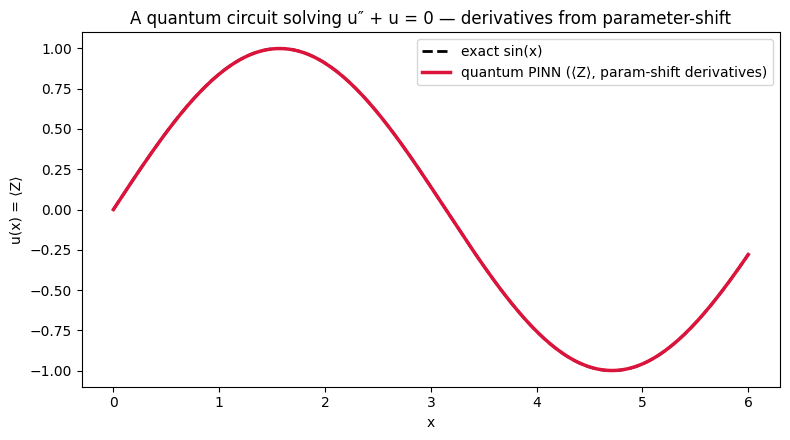

max error vs sin(x): 0.0006


In [15]:
Zo = torch.tensor([[1, 0], [0, -1]], dtype=torch.cfloat)

def u_circuit(x, p):
    psi = torch.tensor([1.0 + 0j, 0.0 + 0j])
    psi = Ry(x) @ psi                                  # single encoding gate -> exact shift rule
    psi = Rz(p[0]) @ psi; psi = Ry(p[1]) @ psi; psi = Rz(p[2]) @ psi   # trainable single-qubit unitary
    return torch.vdot(psi, Zo @ psi).real

torch.manual_seed(0)
p = (torch.rand(3) * 6.28).requires_grad_(True)
opt = torch.optim.Adam([p], lr=0.05)
PI, HALF = torch.pi, torch.pi / 2

for step in range(1500):
    opt.zero_grad()
    xs = torch.rand(16) * 6.0
    res = []
    for x in xs:
        u_xx = 0.25 * (u_circuit(x + PI, p) - 2 * u_circuit(x, p) + u_circuit(x - PI, p))
        res.append(u_xx + u_circuit(x, p))             # residual of u'' + u = 0
    res = torch.stack(res)
    u0 = u_circuit(torch.tensor(0.0), p)
    u0_x = 0.5 * (u_circuit(torch.tensor(HALF), p) - u_circuit(torch.tensor(-HALF), p))
    loss = (res ** 2).mean() + u0 ** 2 + (u0_x - 1.0) ** 2     # + BCs u(0)=0, u'(0)=1
    loss.backward(); opt.step()

xt = torch.linspace(0, 6, 200)
with torch.no_grad(): pq = torch.stack([u_circuit(x, p) for x in xt])
print("final loss:", round(loss.item(), 5))

plt.figure(figsize=(8, 4.5))
plt.plot(xt, torch.sin(xt), 'k--', lw=2, label='exact sin(x)')
plt.plot(xt, pq, 'crimson', lw=2.5, label='quantum PINN (⟨Z⟩, param-shift derivatives)')
plt.title('A quantum circuit solving u″ + u = 0 — derivatives from parameter-shift')
plt.xlabel('x'); plt.ylabel('u(x) = ⟨Z⟩'); plt.legend(); plt.tight_layout(); plt.show()
print("max error vs sin(x):", round((pq - torch.sin(xt)).abs().max().item(), 4))

## The bridge to Pasqal's DQC

| Physics-informed NN (here) | Differentiable Quantum Circuit (Pasqal) |
|----------------------------|-----------------------------------------|
| `model(x)` = neural net | `u(x)` = quantum-circuit expectation |
| `du/dx` via autograd | `du/dx` via **parameter-shift** (Lesson 09) |
| Residual + BC loss | the same loss |
| Adam over weights | Adam over circuit angles |

Because parameter-shift gives *exact* derivatives of a circuit's output, the identical residual loss trains a
quantum model — the heart of Pasqal's DQC, and why their neutral-atom platform is pitched for **scientific
computing**, not just classification.

---

### The arc, nearly complete

- **Lesson 09** built the variational circuit and the gradient (parameter-shift) that makes it trainable on
  hardware, and showed the **encoding's inductive bias** first-hand.
- **Lesson 10** explained *what* such a circuit can represent (a Fourier series, frequencies set by the
  encoding) and how **symmetry** turns raw expressivity into *trainable, generalizing* expressivity.
- **Lesson 11** put a differential equation in the loss and solved it with both a neural net and a real
  (simulated) **quantum** circuit.

**Next:** Lesson 12 — the capstone — stitches kernels, variational circuits, and a classical head into one
**hybrid quantum-classical pipeline**.

*References:* Qadence `arXiv:2401.09915`; geometric/equivariant QML `arXiv:2509.14337`; Pasqal DQC for
physics-informed ML.